<a href="https://colab.research.google.com/github/Dreeck/ProyectosML/blob/Proyecto2/billetesfalsos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving data_banknote_authentication.txt to data_banknote_authentication (4).txt


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
Billetes = pd.read_csv('data_banknote_authentication.txt',sep=',', low_memory=False)
Billetes.head()


,3.6216,8.6661,-2.8073,-0.44699,0
0,4.54590,8.1674,-2.4586,-1.46210,0
1,3.86600,-2.6383,1.9242,0.10645,0
2,3.45660,9.5228,-4.0112,-3.59440,0
3,0.32924,-4.4552,4.5718,-0.98880,0
4,4.36840,9.6718,-3.9606,-3.16250,0


In [ ]:
# prompt: Ponle etiquetas de cabeceras de cada columna los siguientes datos, Varianza,  Asimetría, Curtosis, Entropía y Clase

Billetes.columns = ['Varianza', 'Asimetria', 'Curtosis', 'Entropia', 'Clase']


In [ ]:
print(Billetes.describe())


          Varianza    Asimetria     Curtosis     Entropia        Clase
count  1371.000000  1371.000000  1371.000000  1371.000000  1371.000000
mean      0.431410     1.917434     1.400694    -1.192200     0.444931
std       2.842494     5.868359     4.310105     2.101683     0.497139
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.774700    -1.711300    -1.553350    -2.417000     0.000000
50%       0.495710     2.313400     0.616630    -0.586650     0.000000
75%       2.814650     6.813100     3.181600     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


In [ ]:
X = Billetes[['Varianza', 'Asimetria', 'Curtosis', 'Entropia']]


In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X

,Varianza,Asimetria,Curtosis,Entropia
0,4.54590,8.16740,-2.4586,-1.46210
1,3.86600,-2.63830,1.9242,0.10645
2,3.45660,9.52280,-4.0112,-3.59440
3,0.32924,-4.45520,4.5718,-0.98880
4,4.36840,9.67180,-3.9606,-3.16250
...,...,...,...,...
1366,0.40614,1.34920,-1.4501,-0.55949
1367,-1.38870,-4.87730,6.4774,0.34179
1368,-3.75030,-13.45860,17.5932,-2.77710
1369,-3.56370,-8.38270,12.3930,-1.28230


In [ ]:
def calculate_metrics(data, labels):
    # Ambas métricas requieren al menos 2 clusters para ser calculadas
    if len(set(labels)) > 1 and len(set(labels)) < len(data):
        sil_score = silhouette_score(data, labels)
        cal_score = calinski_harabasz_score(data, labels)
        return sil_score, cal_score
    else:
        # Si solo hay 1 cluster, las métricas no son aplicables
        return 'N/A', 'N/A'

In [ ]:
kmeans = KMeans(n_clusters=2, n_init='auto', random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_sil, kmeans_cal = calculate_metrics(X_scaled, kmeans_labels)

In [ ]:
dbscan = DBSCAN(eps=2.5)
dbscan_labels = dbscan.fit_predict(X_scaled)
dbscan_sil, dbscan_cal = calculate_metrics(X_scaled, dbscan_labels)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

In [ ]:
hierarchical = AgglomerativeClustering(n_clusters=2)
hierarchical_labels = hierarchical.fit_predict(X_scaled)
hierarchical_sil, hierarchical_cal = calculate_metrics(X_scaled, hierarchical_labels)


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['Componente Principal 1', 'Componente Principal 2'])
df_pca['K-Means'] = kmeans_labels
df_pca['DBSCAN'] = dbscan_labels
df_pca['Jerárquico'] = hierarchical_labels

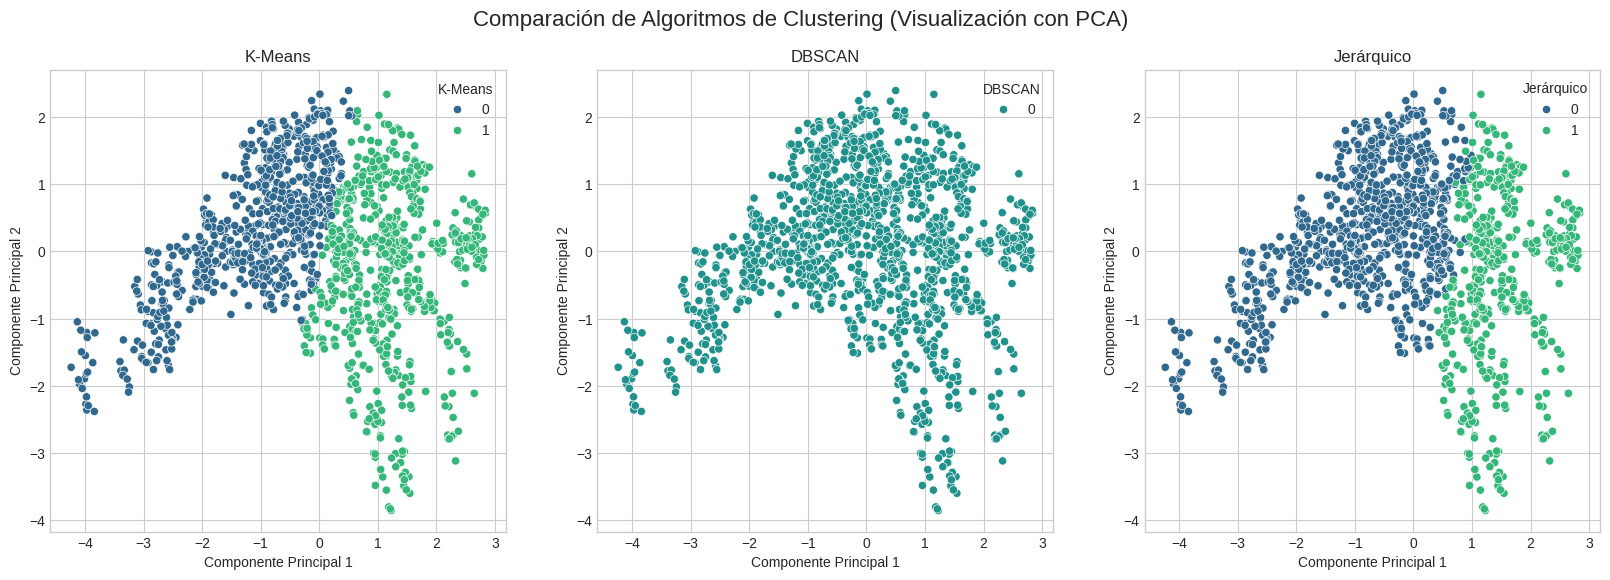

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Comparación de Algoritmos de Clustering (Visualización con PCA)', fontsize=16)
sns.scatterplot(ax=axes[0], x='Componente Principal 1', y='Componente Principal 2', hue='K-Means', palette='viridis', data=df_pca, legend='full').set_title('K-Means')
sns.scatterplot(ax=axes[1], x='Componente Principal 1', y='Componente Principal 2', hue='DBSCAN', palette='viridis', data=df_pca, legend='full').set_title('DBSCAN')
sns.scatterplot(ax=axes[2], x='Componente Principal 1', y='Componente Principal 2', hue='Jerárquico', palette='viridis', data=df_pca, legend='full').set_title('Jerárquico')
plt.show()


--- Visualización de la Estructura Jerárquica (Dendrograma) ---


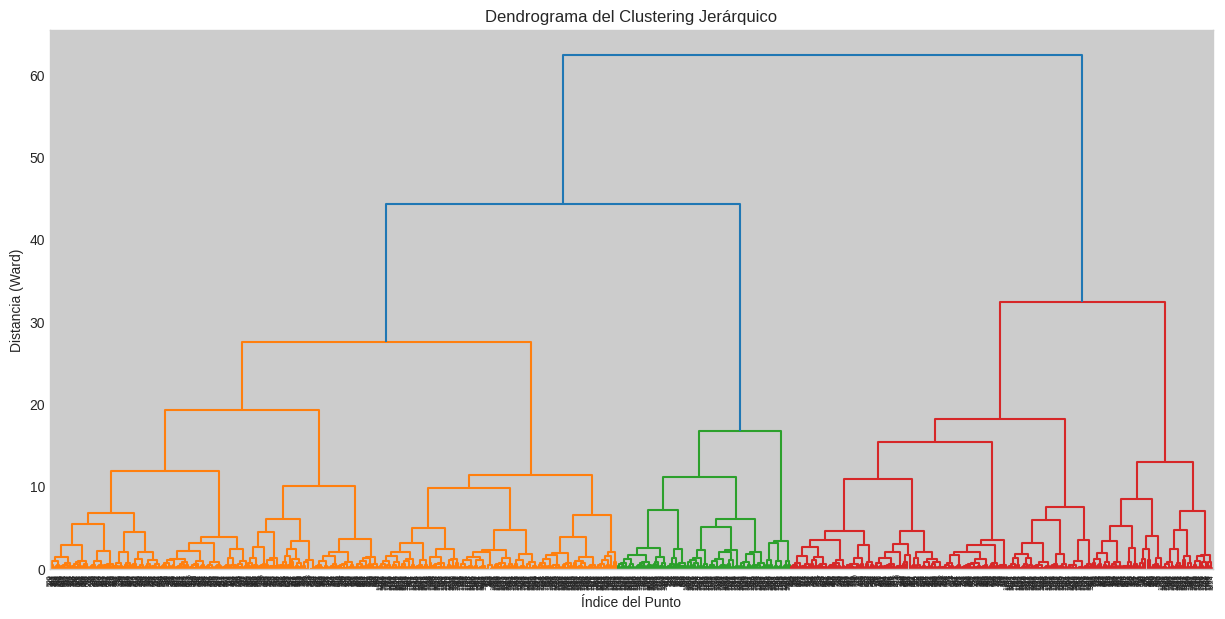

In [ ]:
print("\n--- Visualización de la Estructura Jerárquica (Dendrograma) ---")
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(15, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrograma del Clustering Jerárquico')
plt.xlabel('Índice del Punto')
plt.ylabel('Distancia (Ward)')
plt.show()

In [ ]:
print("--- Tabla Comparativa de Métricas Numéricas ---")
metrics_data = {
    "Algoritmo": ["K-Means", "DBSCAN", "Jerárquico"],
    "Clusters Encontrados": [len(set(kmeans_labels)), n_clusters_dbscan, len(set(hierarchical_labels))],
    "Silhouette Score (Más alto es mejor)": [kmeans_sil, dbscan_sil, hierarchical_sil],
    "Calinski-Harabasz (Más alto es mejor)": [kmeans_cal, dbscan_cal, hierarchical_cal]
}
metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string())


--- Tabla Comparativa de Métricas Numéricas ---
    Algoritmo  Clusters Encontrados Silhouette Score (Más alto es mejor) Calinski-Harabasz (Más alto es mejor)
0     K-Means                     2                             0.329505                            806.590332
1      DBSCAN                     1                                  N/A                                   N/A
2  Jerárquico                     2                             0.330576                            750.427795
